# <span style="color:blue"> Computer Vision — Spring 2026

## Exercise 3

**Deadline:** June 7, 23:55. \
If you need more time, please send a private Piazza message letting me know that you'll submit late. An extention of up to 1 week is automatically approved.

---



In this exercise, you will practice projection matrices and epipolar geometry related tasks.

## Submission guidelines (Note the change in the submission filename!)

1. Your submission should include the following files only:
   - `hw3_Group_<GROUP_NUMBER>_<ID>_<ID>.ipynb` \
     Replace \<ID\> with your ID number(s). \
     Replace \<GROUP_NUMBER\> with the your moodle group number.
   - All image files used in your experiments.
3. Use Jupyter Notebook.
4. Submit this assignment in pairs (no triplets, singles ok).
   * One student should submit the homework, and the other should not submit anything.
   * If you are not the one submitting, make sure that your collaborator indeed submits!

## Read the following instructions carefully

1. Write **efficient vectorized** code.
2. You are responsible for the correctness of your code and should add as many tests as you see fit.
3. Use `Python 3` and `NumPy 1.3.2` or above. Before submitting the exercise, restart the kernel and run the notebook from start to finish to make sure everything works.
4. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/) and [NumPy](https://www.numpy.org/devdocs/reference/) only. Any other imports are forbidden unless provided by us.
5. Your code must run without errors. **Code that fails to run will not be graded.**
6. Document your code properly.

## Honor Code
The assignment is a basic tool for learning the material. You can probably find the solution on the web, but then you will not learn anything from it.
You are more than welcome to discuss the assignment with your friends, but you are not allowed to give your code or answers and you are not allowed to use their code or answers.
Feel free to use AI, but you are expected to understand every piece of code that you submit. Please re-read the course's AI policy.
Remember — you take this course in order to learn. Also, the final exam will contain a lot of material from the assignments. 😀

### I declair that I respect the honor code, and that I understand the course's plagiarism policy and AI policy.
<span style="color:red"> \<Mendel Setti\>

In [1]:
import cv2

# This opens an inteactive figure - use it in part B
import matplotlib
matplotlib.use('TkAgg')

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import null_space

# This specifies the way plots behave in jupyter notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (8.0, 8.0) # set default size of plots
plt.rcParams['image.cmap'] = 'gray'


In [2]:
import platform
print("Python version: ", platform.python_version())
print("Numpy version: ", np.__version__)
print("OpenCV version: ", cv2.__version__)

Python version:  3.12.12
Numpy version:  2.3.3
OpenCV version:  4.13.0


## <span style="color:blue">Section A: Projection

In this part you will go over projection matrix,  and use them to project 3D points to an image.



## <span style="color:blue">Part A1: Projection Matrix 
Fill the missing values, given partial values of the parameters of the left and right cameras.




**Right image parameters:**
The projection matrix of the right image:

In [3]:
MR = np.array([[1100.504780,          0,   331.023000,   0],
               [0,          1097.763735,   259.386377,   0],
               [0,                    0,            1,   0]])

The rotation matrix of the right image:

In [4]:
RR = np.array([[1,0,0],
               [0,1,0],
               [0,0,1]])

The focal length of the right image:

In [5]:
fR = 1.0

The following explanations are for myself to help me sums up the courses topics.

- `OxR` and `OyL` are the principal points of the camera, i.e. the 2D coordinates of the true center of the image.
- `SxR` and `SyR` are the scale factors, i.e. the number of pixels per physical unit of measurements (like mm for example). Multiplying the focal length `fR` of the camera by these scale factors results in the effective focal length per pixel units.
- `MintR` is the right intrinsic matrix. It serves as a bridge between the physical 3D world inside the cam and the 2D image produced:
    $$
    \text{MintR} = \begin{bmatrix}
    f_x & s & OxR \\
    0 & f_y & OyR \\
    0 & 0 & 1
    \end{bmatrix}
    $$
    where $f_x = fR * SxR$ and $f_y = fR * SyR$
- The projection matrix `MR` is equal to $K[R|t]$ where K is `MintR`, R is the rotation matrix (in our case $I$) and t is the translation vector

From here on, replace "none" with your answers to the questions. In addition, if there are more than a single possible solution, choose one.
Compute the right image center (principal point):


In [6]:
OxR = 331.023000 # 1100.504780
OyR = 259.386377 # 1097.763735

Compute the right image scale factor which is consistent with MR:

In [7]:
SxR = 1100.504780 # 331.023000
SyR = 1097.763735 # 259.386377

Compute the right image intrinsic matrix which is consistent with MR:

In [8]:
MintR = np.array([[1100.504780,          0,   331.023000],
                  [0,           1097.763735,   259.386377],
                  [0,                     0,            1]])

 
**Left image parameters**
 
Left image center (principal point):

In [9]:
OxL = 320.798101 
OyL = 236.431326

Scale factor:

In [10]:
SxL = 1095.671499
SyL = 1094.559584 

Focal length of the left image: 

In [11]:
fL = 1

Translation vector w.r.t. the world origin:

In [12]:
TL = -np.array([[178.2218,18.8171,-13.7744]]).T

Rotation matrix of the left image:

In [13]:
RL = np.array([[ 0.9891,    0.0602,   -0.1346],
               [-0.0590,    0.9982,    0.0134],
               [0.1351,   -0.0053,    0.9908]])

In [14]:
f_x_l = fL * SxL
f_y_l = fL * SyL 

Compute the intrinsic projection matrix of the left camera: 

In [15]:
MintL = np.array([[f_x_l,    0,   OxL],
                  [0,     f_y_l,   OyL],
                  [0,         0,     1]])

Compute the projection matrix of the left camera

In [16]:
tL = -RL @ TL
extrinsicL = np.hstack((RL, tL)) # TL
ML = MintL @ extrinsicL

Compute the COP of the left and the right images, in Cartesian coordinates:   

(You may use the the function *null_space* from *scipy.linalg*) 

Standard Extrinsic equation:  
$X_c = R*X_w + t$

In our case, since we want to compute the COP we do:
$0 = R*C + t$ which gives us $R*C = -t$ where C stands for the center of projection. 
Since $R^{-1} = R^T$ we get $C = -R^T t$ 

In [17]:
'''CL = -RL.T @ TL
CR = np.array([0,0,0]).T
print("CR is",CR)
print("CL is",CL)'''

'CL = -RL.T @ TL\nCR = np.array([0,0,0]).T\nprint("CR is",CR)\nprint("CL is",CL)'

In [18]:
# Right Camera COP
# Find the null space 
C_R_homo = null_space(MR)

# Convert from homogeneous to Cartesian
CR = (C_R_homo[:3] / C_R_homo[3]).flatten()


# Left Camera COP 
# Find the null space
C_L_homo = null_space(ML)

# Convert from homogeneous to Cartesian
CL = (C_L_homo[:3] / C_L_homo[3]).flatten()
print("CR is",CR)
print("CL is",CL)

CR is [0. 0. 0.]
CL is [-178.2218  -18.8171   13.7744]


In [19]:
TL.flatten()

array([-178.2218,  -18.8171,   13.7744])

Compute the distance between CL and CR:
    

In [20]:
D = np.linalg.norm(CR.flatten() - CL.flatten())
print("The Distance is: ", D)

The Distance is:  179.74100072885088


## <span style="color:blue">Part A2: Hands on Triangulation

Write a function p = proj(M,P) that recieves as input the 3D point P in Euclidean coordinates and a projection matrix M, and outputs the 2D  Euclidean coordinates of the projected point.


In [21]:
def proj(M,P):
    homogeneous_P = np.append(P,[1.0])
    homogeneous_P = M @ homogeneous_P
    projection = homogeneous_P[:2] / homogeneous_P[2] 
    return projection

**<span style="color:blue">Answer Quesion:**\
Given object points in the world coordinate system,  $P=(-140,50,1200)$ and $Q=(30,100,2000)$.

a.	What are the coordinates (Euclidean) of the points in the left camera coordinate system?\
b.	What are the coordinates (Euclidean) of the points in the right camera coordinate system?
    
Note: the camera coordinate system rather than the image coordinate system. (PL means the 3D coordinates in the left **camera** cordinates system, and pL means the 2D coordinates in the left **image** coordinates system.)
   

**<span style="color:blue">Your answer:**

In [22]:
print("Left projection matrix is: ", ML)

Left projection matrix is:  [[ 1.12706850e+03  6.42591943e+01  1.70369375e+02  1.99730613e+05]
 [-3.26371433e+01  1.09133629e+03  2.48923256e+02  1.12903652e+04]
 [ 1.35100000e-01 -5.30000000e-03  9.90800000e-01  1.03303590e+01]]


In [23]:
print("Right projection matrix is: ", MR)

Right projection matrix is:  [[1.10050478e+03 0.00000000e+00 3.31023000e+02 0.00000000e+00]
 [0.00000000e+00 1.09776373e+03 2.59386377e+02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]


In [24]:
P = np.array([-140, 50, 1200])
Q = np.array([30, 100, 2000])

PL = None
PR = None
QL = None
QR = None

In [25]:
P = np.array([[-140],[50],[1200]])
pL = proj(ML,P)
pR = proj(MR,P)

Q = np.array([[30],[100],[2000]]) 
qL = proj(ML,Q)
qR = proj(MR,Q)

### Read two images and display the projections of P and Q on the two given images ###

(<matplotlib.image.AxesImage at 0x2547ee27290>,
 Text(0.5, 1.0, 'Right image'),
 <matplotlib.collections.PathCollection at 0x2547ee4d370>)

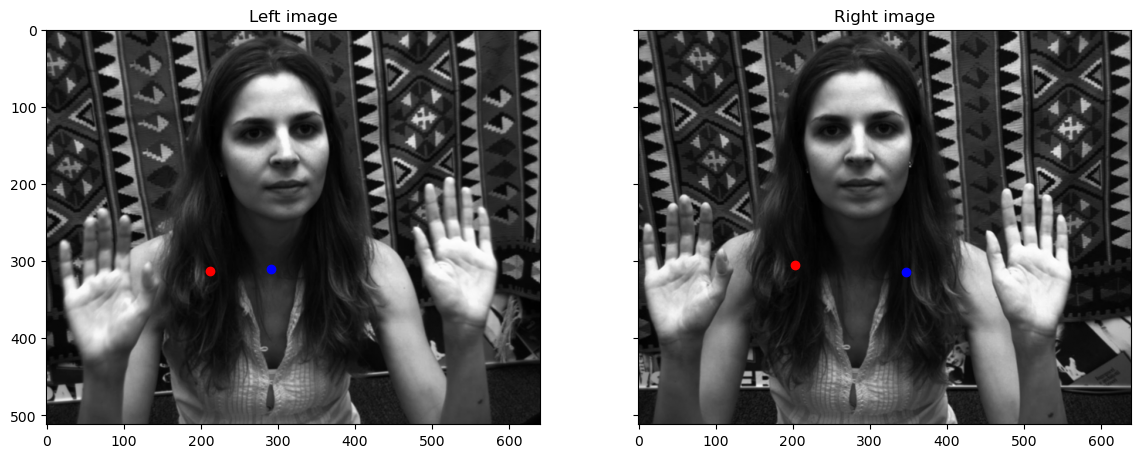

In [26]:
imL = cv2.imread('left.tif', cv2.IMREAD_GRAYSCALE)
imR = cv2.imread('right.tif', cv2.IMREAD_GRAYSCALE)
    
plt.rcParams['figure.figsize'] = (14.0, 14.0) 
f, ((ax1, ax2)) = plt.subplots(1, 2, sharex='col', sharey='row')

ax1.imshow(imL, cmap='gray'), ax1.set_title('Left image'), ax1.scatter(pL[0], pL[1], color='r'), \
    ax1.scatter(qL[0],qL[1], color = 'b')
ax2.imshow(imR, cmap='gray'), ax2.set_title('Right image'), ax2.scatter(pR[0], pR[1], color = 'r'), \
    ax2.scatter(qR[0],qR[1], color = 'b')

**<span style="color:blue"> Answer Question:**\
Look at the projection of each of the points in the two images. One pair looks as expected, and the other does not. Please give a short explanation of what may have caused it.

**<span style="color:blue">Your answer:**\
As we can see above, the red pair looks fine while the blue pair is off by quite a bit. 
A possible reason is that the provided translation vector represents the camera center with respect to the world origin, not directly the extrinsic translation vector t used in the projection matrix. 
In the projection matrix P = K[R|t], the correct translation is t = -RC. Using the camera center directly as t causes incorrect projections.
    
    
    

## <span style="color:blue"> Part B: Epipolar Geometry
Compute the fundamental matrix F and the epipoles eL and eR of the left and right images, using their projection matrices.\
Note, you should normalize F by F(3,3) for improved precision.

For the epipoles' computation use the MR and ML and the Center of projections.

**<span style="color:blue">Answer Question:**
Can you double check if they are correct using F? If so, check it.


**<span style="color:blue">Your answer:**\
   ...
    
    
    

In [27]:
CL_homogeneous = null_space(ML)
CL_homogeneous = CL_homogeneous / CL_homogeneous[3]

print("CL homogeneous is: ", CL_homogeneous)
print("CL is: ", CL)

CL_homogeneous2 = np.append(CL,[1.0])
print("CL homogeneous take 2 is: ", CL_homogeneous)

CR_homogeneous = np.append(CR,[1.0])
print("CR homogeneous is: ", CR_homogeneous.T)
print("CR is: ", CR)

CL homogeneous is:  [[-178.2218]
 [ -18.8171]
 [  13.7744]
 [   1.    ]]
CL is:  [-178.2218  -18.8171   13.7744]
CL homogeneous take 2 is:  [[-178.2218]
 [ -18.8171]
 [  13.7744]
 [   1.    ]]
CR homogeneous is:  [0. 0. 0. 1.]
CR is:  [0. 0. 0.]


To get the value of the fundamental matrix `F` I will use the following equation:
$F = [e_R] \times M_R M_L^{-1}$

In [28]:
eL = ML @ CR_homogeneous
eR = MR @ CL_homogeneous

eL_cartesian = proj(ML, CR)
eR_cartesian = proj(MR, CL)

def skew(v):
    v = v.flatten()
    return np.array([[0, -v[2], v[1]],
                     [v[2], 0, -v[0]],
                     [-v[1], v[0], 0]])

F = skew(eR) @ MR @ np.linalg.pinv(ML)

In [29]:
F.shape

(3, 3)

## Epipolar lines ##

Click on three different points of the **right** image, and check if the epipolar lines on the left image pass through a pixel that corresponds to the one you picked in the right image. Output the set of epipolar lines overlayed on the pair of  images as shown below.

To do so you can use:
1. The code below opens the images in a seperate window. You can click on the right image and  capture the click's coordinates by using the function *plt.ginput*.
2. Take each point (this can be done by a loop) and calculate its epipolar line  on the left image using F.
3. Compute the two endpoints of the line in the image to plot it on the left image. \
    **Hint**: you have linear coefficients - (a,b,c). Calculate the y value in the image for x=0, and x=image.width and plot the result.\
    Use: ax2.plot((x0. xWidth),(yx0, yxWidth))
4. Use the set of the points of the right image that you collected, and draw the epipolar lines on the right image.

In [ ]:
# This sould open a new figure window outside of jupyter notebook
%matplotlib qt  

imL = cv2.imread('left.tif', cv2.IMREAD_GRAYSCALE)
imR = cv2.imread('right.tif', cv2.IMREAD_GRAYSCALE)

imL_height ,imL_width = imL.shape
imR_width = imR.shape[1]


plt.rcParams['figure.figsize'] = (14.0, 14.0) 
f, ((ax1, ax2)) = plt.subplots(1, 2, sharex='col', sharey='row')

ax1.imshow(imL, cmap='gray'), ax1.set_title('Left image')
ax2.imshow(imR, cmap='gray'), ax2.set_title('Right image')

data = plt.ginput(3)

x_val = [x[0] for x in data]
y_val = [x[1] for x in data]

ax2.scatter(x_val, y_val, color='r')


colors = ['b', 'orange', 'g']

for i, x in enumerate(data):
    p = np.array([x[0],x[1],1.0])
    epiline = F.T @ p
    a, b, c = epiline
    x0 = 0
    x1 = imL_width - 1
    if abs(b) > 1e-10:
        y0 = -(a * x0 + c) / b
        y1 = -(a * x1 + c) / b
        ax1.plot((x0, x1), (y0, y1), color=colors[i])
    else:
        x_vertical = -c / a
        ax1.plot((x_vertical, x_vertical), (0, imL_height - 1), color=colors[i])  
    print("Clicked right point:", x)
    print("Epipolar line in left image: a*x + b*y + c = 0")
    print("a =", a, "b =", b, "c =", c)
    print()  

plt.show()

Clicked right point: (np.float64(269.6566820276498), np.float64(86.79953917050693))
Epipolar line in left image: a*x + b*y + c = 0
a = 10368.234627926951 b = -196977.3381365477 c = 14819641.948499097

Clicked right point: (np.float64(62.02534562211986), np.float64(221.75990783410134))
Epipolar line in left image: a*x + b*y + c = 0
a = 8610.710090169585 b = -193848.59416440802 c = 45380708.660162084

Clicked right point: (np.float64(224.23732718894007), np.float64(465.72672811059897))
Epipolar line in left image: a*x + b*y + c = 0
a = 6350.029827337831 b = -195740.7033169056 c = 91157400.14685926



In [58]:
%matplotlib inline

In [59]:
%matplotlib qt

imL = cv2.imread('left.tif', cv2.IMREAD_GRAYSCALE)
imR = cv2.imread('right.tif', cv2.IMREAD_GRAYSCALE)

plt.rcParams['figure.figsize'] = (14.0, 14.0) 
fig, (ax1, ax2) = plt.subplots(1, 2, sharex='col', sharey='row')

ax1.imshow(imL, cmap='gray')
ax1.set_title('Left image')

ax2.imshow(imR, cmap='gray')
ax2.set_title('Right image')

# Click 3 points in the RIGHT image
data = plt.ginput(3)

plt.close(fig)

print("Clicked points:")
for p in data:
    print(p)

Clicked points:
(np.float64(269.6566820276498), np.float64(159.47050691244237))
(np.float64(50.346082949308766), np.float64(304.81244239631326))
(np.float64(333.2437788018433), np.float64(470.9175115207372))


Clicked right point: (np.float64(269.6566820276498), np.float64(159.47050691244237))
Epipolar line in left image: a*x + b*y + c = 0
a = 9612.469379104434 b = -196862.4841486508 c = 29306332.35477689

Clicked right point: (np.float64(50.346082949308766), np.float64(304.81244239631326))
Epipolar line in left image: a*x + b*y + c = 0
a = 7727.068098866637 b = -193553.33875532862 c = 62142644.50421194

Clicked right point: (np.float64(333.2437788018433), np.float64(470.9175115207372))
Epipolar line in left image: a*x + b*y + c = 0
a = 6481.875859999743 b = -197263.1074078011 c = 90272126.86980546



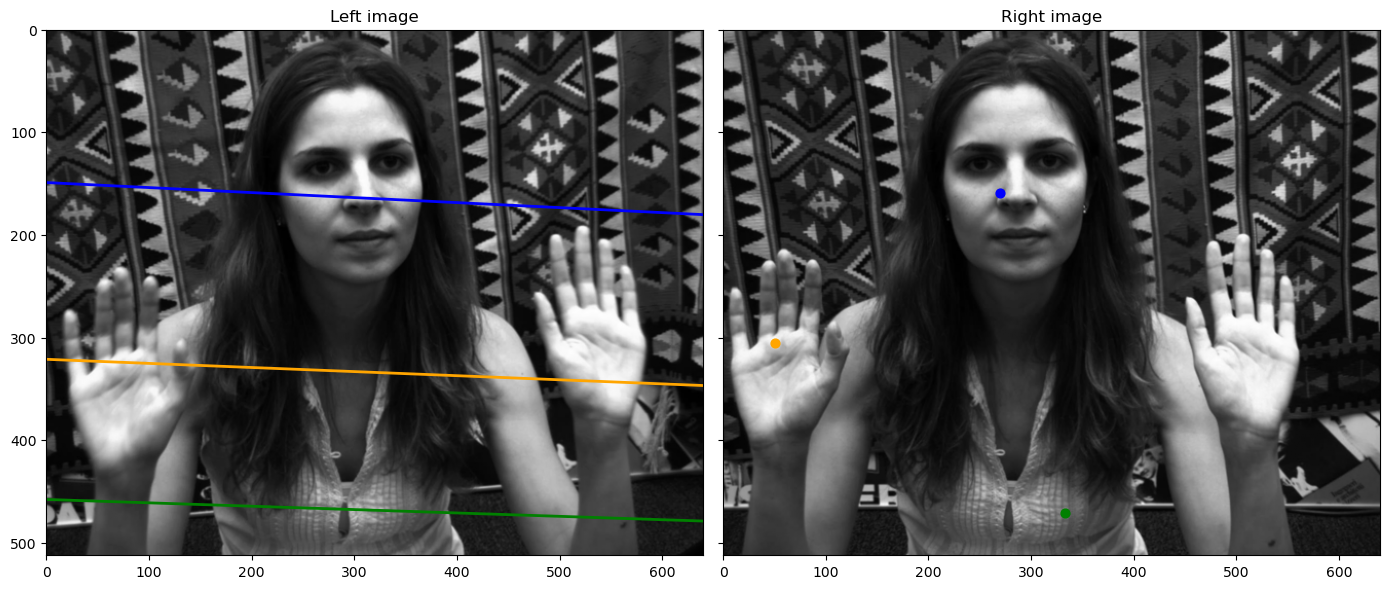

In [60]:
%matplotlib inline

def line_endpoints(line, width, height):
    """
    Convert a line ax + by + c = 0 into two endpoints for plotting.
    """
    a, b, c = line

    x0 = 0
    x1 = width - 1

    if abs(b) > 1e-8:
        y0 = -(a * x0 + c) / b
        y1 = -(a * x1 + c) / b
        return (x0, x1), (y0, y1)
    else:
        x = -c / a
        return (x, x), (0, height - 1)

imL_height, imL_width = imL.shape
imR_height, imR_width = imR.shape

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharex='col', sharey='row')

ax1.imshow(imL, cmap='gray')
ax1.set_title('Left image')

ax2.imshow(imR, cmap='gray')
ax2.set_title('Right image')

colors = ['b', 'orange', 'g']

for i, point in enumerate(data):
    xR, yR = point

    p = np.array([xR, yR, 1.0])

    # Since pR.T @ F @ pL = 0,
    # the epipolar line in the left image is F.T @ pR
    epiline = F.T @ p

    a, b, c = epiline

    x_vals, y_vals = line_endpoints(epiline, imL_width, imL_height)

    # Draw epipolar line on left image
    ax1.plot(x_vals, y_vals, color=colors[i], linewidth=2)

    # Draw clicked point on right image
    ax2.scatter(xR, yR, color=colors[i], s=40)

    print("Clicked right point:", point)
    print("Epipolar line in left image: a*x + b*y + c = 0")
    print("a =", a, "b =", b, "c =", c)
    print()

# Keep axes inside image boundaries
ax1.set_xlim(0, imL_width)
ax1.set_ylim(imL_height, 0)

ax2.set_xlim(0, imR_width)
ax2.set_ylim(imR_height, 0)

plt.tight_layout()
plt.show()

### This is what you should see:
![Epipolar](epipolarLines1.png "Epipolar Lines example")

##  <span style="color:blue">Part C : SIFT and RANSAC/LMedS</span>

**Follow the matching to compute F.**

Make sure you remember RANSAC, and read a bit about LMedS. Ask yourself: what are the commonalities between the two methods? What are the differences? (Not for submission.)

Go over this epipolar geometry tutorial:
https://docs.opencv.org/master/da/de9/tutorial_py_epipolar_geometry.html 

Below, we find the corresponding featues using the SIFT algorithm and match the closet points. The plotted figure showes the best 300 matches.

❗️Important: SIFT was a patented algorithm and was thus not distributed with vanilla OpenCV. This changed when the patent expired in 2020. If you are getting errors (e.g., missing `cv2.SIFT_create()`) make sure you are using a recent version of OpenCV.

(<matplotlib.image.AxesImage at 0x25400bdaf00>, Text(0.5, 1.0, 'Matches'))

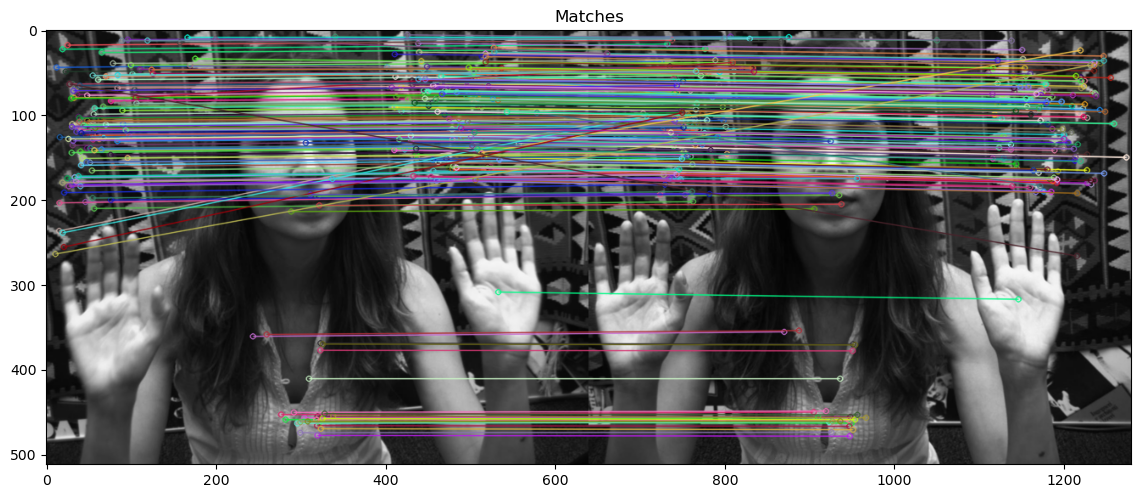

In [48]:
%matplotlib inline
imL = cv2.imread('left.tif', cv2.IMREAD_GRAYSCALE)
imR = cv2.imread('right.tif', cv2.IMREAD_GRAYSCALE)

# Initiate SIFT detector
sift = cv2.SIFT_create()

# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(imL, None)
kp2, des2 = sift.detectAndCompute(imR, None)

# FLANN parameters
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)
# create FlannBasedMatcher object
flann = cv2.FlannBasedMatcher(index_params,search_params)

# Match descriptors.
matches = flann.knnMatch(des1, des2, k=2)

pts1 = []
pts2 = []
matching = []
# Building a list of points screened by ratio test as per Lowe's paper
for i,(m,n) in enumerate(matches):
    if m.distance < 0.8*n.distance:
        pts2.append(kp2[m.trainIdx].pt)
        pts1.append(kp1[m.queryIdx].pt)
        matching.append(m)
        
# Sort them in the order of their distance.
matching = sorted(matching, key = lambda x:x.distance)
        
# Draw first 300 matches.
img3 = np.array([])
img3 = cv2.drawMatches(imL, kp1, imR, kp2, matching[:300], outImg = img3, flags=2)

plt.rcParams['figure.figsize'] = (14.0, 14.0) 
f, ((ax1)) = plt.subplots(1, 1, sharex='col', sharey='row')
ax1.imshow(img3, cmap='gray'), ax1.set_title('Matches')

<span style="color:blue"> Not for submission:</span>

Look at the obtained results.

1. Do you think all matches are correct?
2. In which regions of the scene most of the reliable matches were found?
3. Try the worst 200 mathces as well (`matching[-200:]`).

Now, we will use the found matches to compute **F** using `cv2.findFundamentalMat()`.

In [49]:
pts1 = np.int32(pts1)
pts2 = np.int32(pts2)

# Computing the F matrix
F_calc, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_LMEDS)
# We select only inlier points
pts1 = pts1[mask.ravel()==1]
pts2 = pts2[mask.ravel()==1]

In [50]:
np.set_printoptions(formatter={'float' : '{:0.7f}'.format})
print(F_calc.T)
print(F)

[[0.0000014 -0.0000066 0.0075087]
 [-0.0000026 -0.0000014 -0.0594727]
 [-0.0097601 0.0617092 1.0000000]]
[[1.7047547 -14.0414436 -17613.9746693]
 [-10.3998236 1.5804659 199346.3257256]
 [10811.2360220 -193328.1527461 2266198.7068321]]


And now lets check the computed F_calc:
1. Use it to draw the epipolar line as in the example above (change F to F_calc.T)
2. Compute the distance between the computed epipoles by F and by F_calc in each of the images.

You can use `scipy.linalg import null_space`

In [51]:
# 1. Draw epilines with F_calc.T
%matplotlib qt

def line_endpoints(line, width, height):
    """
    Convert a line ax + by + c = 0 into two endpoints for plotting.
    """
    a, b, c = line

    x0 = 0
    x1 = width - 1

    if abs(b) > 1e-8:
        y0 = -(a * x0 + c) / b
        y1 = -(a * x1 + c) / b
        return (x0, x1), (y0, y1)
    else:
        x = -c / a
        return (x, x), (0, height - 1)

imL = cv2.imread('left.tif', cv2.IMREAD_GRAYSCALE)
imR = cv2.imread('right.tif', cv2.IMREAD_GRAYSCALE)

hL, wL = imL.shape
hR, wR = imR.shape

plt.rcParams['figure.figsize'] = (14.0, 14.0)
fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.imshow(imL, cmap='gray')
ax1.set_title('Left image')

ax2.imshow(imR, cmap='gray')
ax2.set_title('Right image')

# Click 3 points in the RIGHT image
data = plt.ginput(3)

colors = ['b', 'orange', 'g']

for i, point in enumerate(data):
    xR, yR = point

    # Right point in homogeneous coordinates
    pR = np.array([xR, yR, 1.0])

    # Draw selected point on right image
    ax2.scatter(xR, yR, color='r')

    # Epipolar line in the LEFT image
    # Because pR.T @ F_calc @ pL = 0
    lL = F_calc.T @ pR

    x_vals, y_vals = line_endpoints(lL, wL, hL)
    ax1.plot(x_vals, y_vals, color=colors[i])

plt.show()

In [ ]:
%matplotlib qt
# Please note that this cell is here to collect the datapoint. The next cell will display the images with the epilines in this notebook instead of popping in another window.

imL = cv2.imread('left.tif', cv2.IMREAD_GRAYSCALE)
imR = cv2.imread('right.tif', cv2.IMREAD_GRAYSCALE)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

ax1.imshow(imL, cmap='gray')
ax1.set_title('Left image')

ax2.imshow(imR, cmap='gray')
ax2.set_title('Right image')

# Click 3 points in the RIGHT image
data = plt.ginput(3)

plt.close(fig)

print(data)

[(np.float64(281.3359447004609), np.float64(169.20322580645166)), (np.float64(285.22903225806454), np.float64(226.30184331797238)), (np.float64(207.36728110599074), np.float64(470.26866359447))]


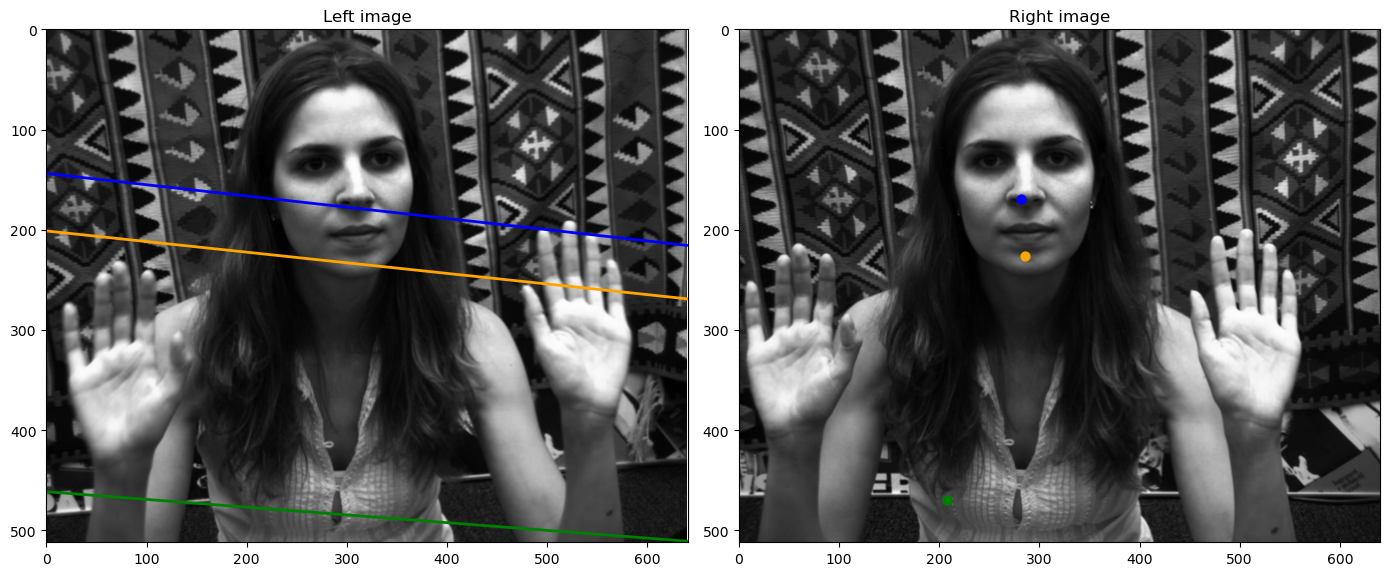

In [55]:
%matplotlib inline

def line_endpoints(line, width, height):
    """
    Convert a line ax + by + c = 0 into two endpoints for plotting.
    """
    a, b, c = line

    x0 = 0
    x1 = width - 1

    if abs(b) > 1e-8:
        y0 = -(a * x0 + c) / b
        y1 = -(a * x1 + c) / b
        return (x0, x1), (y0, y1)
    else:
        x = -c / a
        return (x, x), (0, height - 1)

hL, wL = imL.shape
hR, wR = imR.shape

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

ax1.imshow(imL, cmap='gray')
ax1.set_title('Left image')

ax2.imshow(imR, cmap='gray')
ax2.set_title('Right image')

colors = ['b', 'orange', 'g']

for i, point in enumerate(data):
    xR, yR = point

    pR = np.array([xR, yR, 1.0])

    # Draw selected point on right image
    ax2.scatter(xR, yR, color=colors[i], s=40)

    # Epipolar line in the left image
    lL = F_calc.T @ pR

    x_vals, y_vals = line_endpoints(lL, wL, hL)
    ax1.plot(x_vals, y_vals, color=colors[i], linewidth=2)

# Keep axes inside the image boundaries
ax1.set_xlim(0, wL)
ax1.set_ylim(hL, 0)

ax2.set_xlim(0, wR)
ax2.set_ylim(hR, 0)

plt.tight_layout()
plt.show()

In [56]:
# 2. Distance between F and F_calc.T

def epipoles_from_F(F):
    """
    Returns left and right epipoles in Cartesian coordinates.
    Assumes pR.T @ F @ pL = 0.
    """
    eL_h = null_space(F)      # F @ eL = 0
    eR_h = null_space(F.T)    # F.T @ eR = 0

    eL_h = eL_h / eL_h[2]
    eR_h = eR_h / eR_h[2]

    eL = eL_h[:2].flatten()
    eR = eR_h[:2].flatten()

    return eL, eR


# Normalize both just for numerical stability
F_norm = F / np.linalg.norm(F)
F_calc_norm = F_calc / np.linalg.norm(F_calc)

eL, eR = epipoles_from_F(F_norm)
eL_calc, eR_calc = epipoles_from_F(F_calc_norm)

print("Epipole from theoretical F:")
print("eL =", eL)
print("eR =", eR)

print("\nEpipole from F_calc:")
print("eL_calc =", eL_calc)
print("eR_calc =", eR_calc)

dist_left = np.linalg.norm(eL - eL_calc)
dist_right = np.linalg.norm(eR - eR_calc)

print("\nDistance between left epipoles:", dist_left)
print("Distance between right epipoles:", dist_right)

Epipole from theoretical F:
eL = [19334.3341250 1092.9305704]
eR = [-13907.9959627 -1240.2600670]

Epipole from F_calc:
eL_calc = [9082.1486051 1163.4842129]
eR_calc = [-20913.4831477 -3323.9418056]

Distance between left epipoles: 10252.42828555719
Distance between right epipoles: 7308.801562924769


**<span style="color:blue">Answer Question:**\
    Do you see any differences?
    
**<span style="color:blue">Your answer:**\
    ...

### <span style="color:blue"> Your part in this section :) ###

#### Take two pictures using your own camera and compute the epipolar geometry using LMedS ####

Please submit: 5 corresponding epipolar lines overlayed on   your pair of images.

F_my:
[[-0.0000007 0.0000051 0.0019179]
 [0.0000094 -0.0000017 -0.0269534]
 [-0.0004036 0.0176974 1.0000000]]


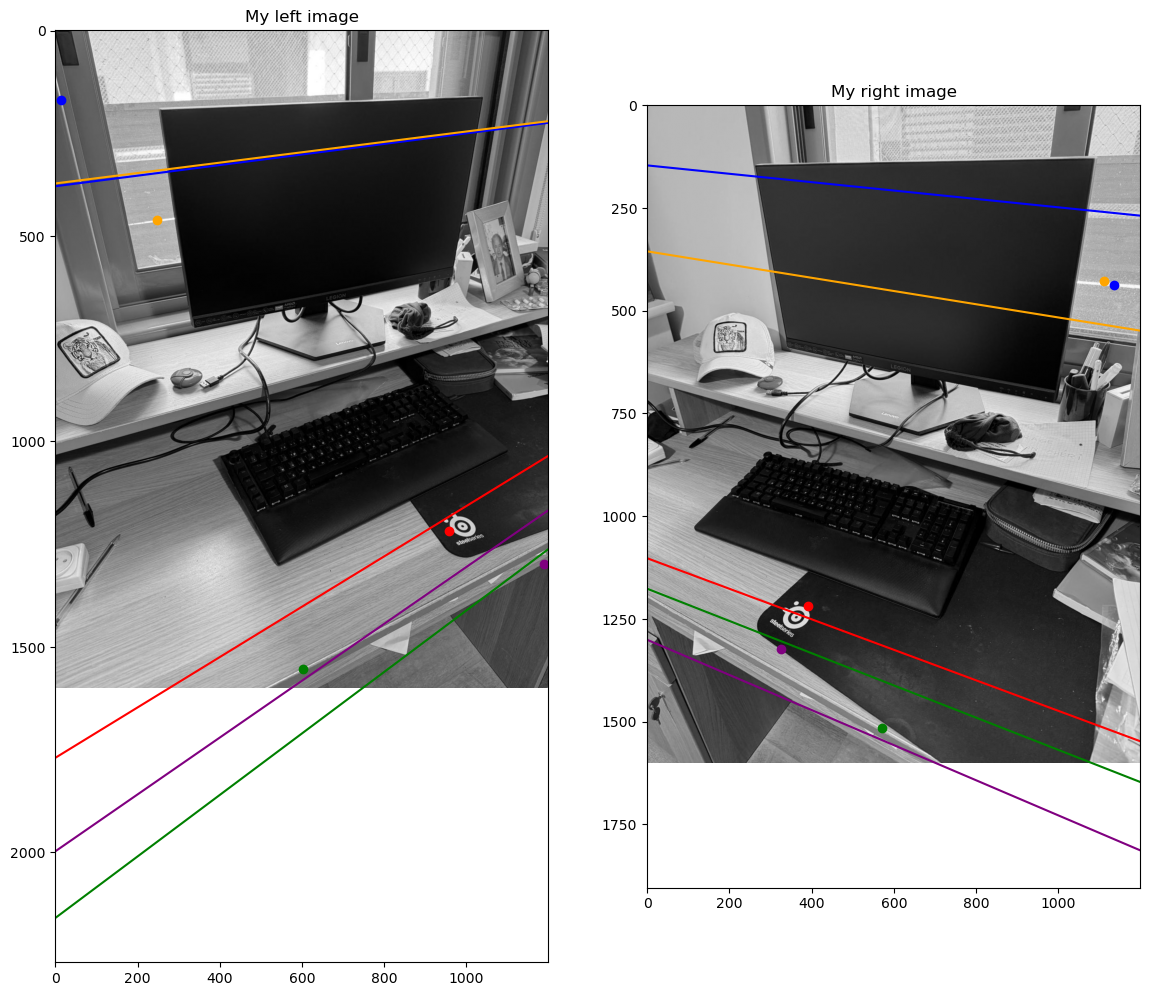

F_my:
[[0.0000006 0.0000043 -0.0064157]
 [-0.0000030 -0.0000005 -0.0047572]
 [0.0044356 0.0041038 1.0000000]]


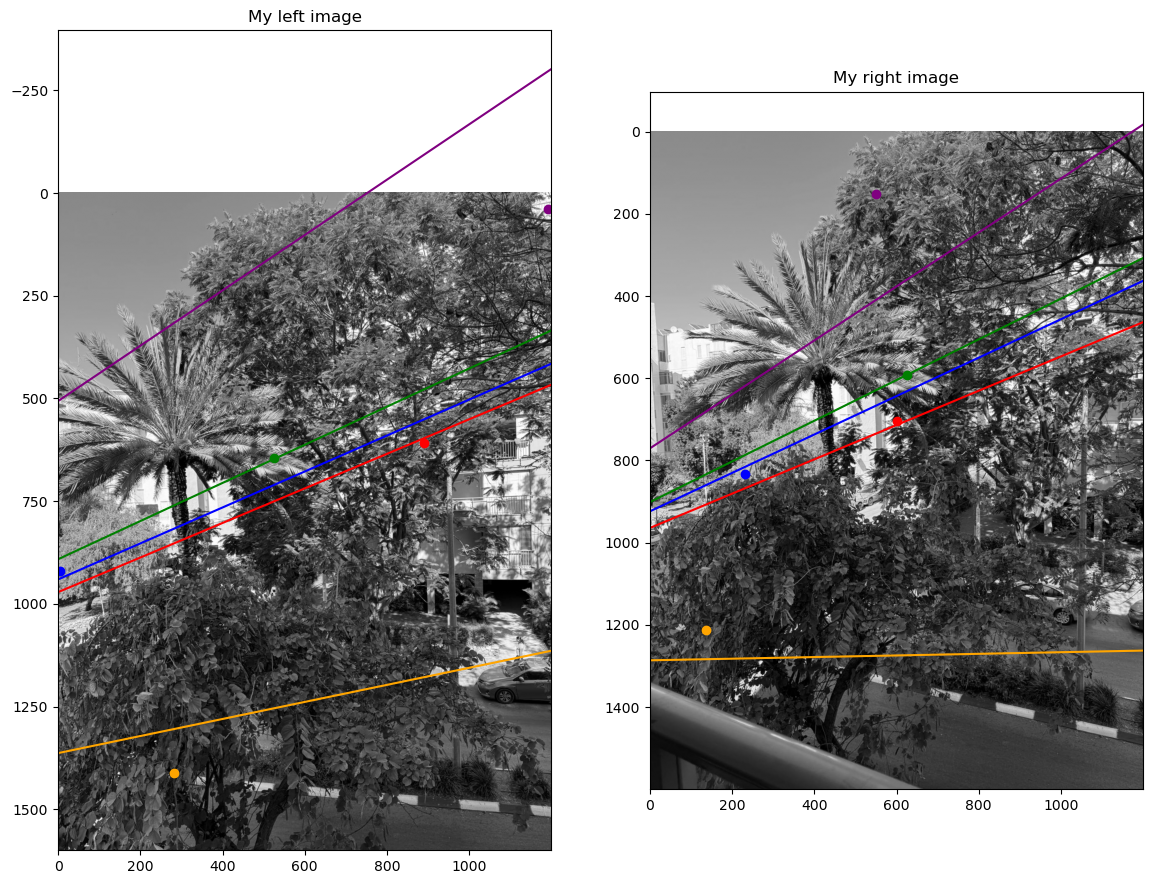

In [57]:
# Please run the cells above since the function line_endpoints if defined in a previous cell
def compute_F_with_sift_lmeds(imL, imR):
    sift = cv2.SIFT_create()

    kp1, des1 = sift.detectAndCompute(imL, None)
    kp2, des2 = sift.detectAndCompute(imR, None)

    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)

    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)

    pts1 = []
    pts2 = []
    good_matches = []

    for m, n in matches:
        if m.distance < 0.8 * n.distance:
            pts1.append(kp1[m.queryIdx].pt)
            pts2.append(kp2[m.trainIdx].pt)
            good_matches.append(m)

    pts1 = np.float32(pts1)
    pts2 = np.float32(pts2)

    F_calc, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_LMEDS)

    if F_calc is None:
        raise ValueError("Could not compute fundamental matrix. Try taking better images.")

    inlier_pts1 = pts1[mask.ravel() == 1]
    inlier_pts2 = pts2[mask.ravel() == 1]

    return F_calc, inlier_pts1, inlier_pts2, kp1, kp2, good_matches

images_pair = [ ('images\desk2L.jpeg','images\desk2R.jpeg'),
                ('images\\balconyL.jpeg','images\\balconyR.jpeg')
            ] #('images\desk1L.jpeg','images\desk1L.jpeg'),hw3\images\balconyR.jpeg

for left_img, right_image in images_pair:
    imL = cv2.imread(left_img, cv2.IMREAD_GRAYSCALE)
    imR = cv2.imread(right_image, cv2.IMREAD_GRAYSCALE)

    if imL is None or imR is None:
        raise ValueError("Could not load one of the images. Check the file names.")

    F_my, ptsL_inliers, ptsR_inliers, kp1, kp2, good_matches = compute_F_with_sift_lmeds(imL, imR)

    print("F_my:")
    print(F_my)

    hL, wL = imL.shape
    hR, wR = imR.shape

    plt.rcParams['figure.figsize'] = (14.0, 14.0)
    fig, (ax1, ax2) = plt.subplots(1, 2)

    ax1.imshow(imL, cmap='gray')
    ax1.set_title('My left image')

    ax2.imshow(imR, cmap='gray')
    ax2.set_title('My right image')

    # Choose 5 inlier correspondences automatically
    num_lines = 5
    indices = np.linspace(0, len(ptsR_inliers) - 1, num_lines, dtype=int)

    colors = ['b', 'orange', 'g', 'r', 'purple']

    for i, idx in enumerate(indices):
        xR, yR = ptsR_inliers[idx]
        xL, yL = ptsL_inliers[idx]

        pR = np.array([xR, yR, 1.0])
        pL = np.array([xL, yL, 1.0])

        # Draw selected matching points
        ax1.scatter(xL, yL, color=colors[i])
        ax2.scatter(xR, yR, color=colors[i])

        # Line in LEFT image for point in RIGHT image
        lL = F_my.T @ pR
        x_vals_L, y_vals_L = line_endpoints(lL, wL, hL)
        ax1.plot(x_vals_L, y_vals_L, color=colors[i])

        # Line in RIGHT image for point in LEFT image
        lR = F_my @ pL
        x_vals_R, y_vals_R = line_endpoints(lR, wR, hR)
        ax2.plot(x_vals_R, y_vals_R, color=colors[i])

    plt.show()